In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class LoRALinear(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.linear = linear_layer
        self.r = r
        self.alpha = alpha
        
        in_dim = linear_layer.in_features
        out_dim = linear_layer.out_features

        self.linear.weight.requires_grad = False
        self.A = nn.Parameter(torch.randn(r, in_dim) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_dim, r))

        self.scaling = alpha / r

    def forward(self, x):
        original = self.linear(x)
        lora_update = (x @ self.A.T) @ self.B.T
        return original + self.scaling * lora_update

In [3]:
class DoraLayer(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.base_layer = linear_layer
        out_features, in_features = linear_layer.weight.shape

        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.scaling = alpha / r

        with torch.no_grad():
            m = torch.linalg.norm(self.base_layer.weight, dim=1, keepdim=True)
        self.m = nn.Parameter(m)

    def forward(self, x):
        delta_v = (self.lora_B.weight @ self.lora_A.weight) * self.scaling
        v_new = self.base_layer.weight + delta_v
        norm_scale = self.m / torch.linalg.norm(v_new, dim=1, keepdim=True).detach()
        base_output = nn.functional.linear(x, self.base_layer.weight)
        lora_output = self.lora_B(self.lora_A(x)) * self.scaling
        result = norm_scale.view(1,1,-1) * (base_output + lora_output)
        if self.base_layer.bias is not None:
            result += self.base_layer.bias
        return result

In [4]:
def inject_lora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, LoRALinear(module, r=r, alpha=alpha)
                )
    return model

In [5]:
def inject_dora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, DoraLayer(module, r=r, alpha=alpha))
    return model

In [6]:
from transformers import BertForSequenceClassification, BertTokenizer

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
model = inject_dora_bert(model)

In [8]:

for name, param in model.named_parameters():
    if "A" in name or "B" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


In [9]:
from datasets import load_dataset

dataset = load_dataset("ag_news")

In [10]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [11]:
train_small = dataset["train"].shuffle(seed=42).select(range(2000))
test_small  = dataset["test"].shuffle(seed=42).select(range(500))

In [12]:
def decompose(W0, W, eps=1e-8):
    # Magnitudes
    m0 = torch.linalg.norm(W0, dim=1, keepdim=True)
    m  = torch.linalg.norm(W, dim=1, keepdim=True)
    delta_M = (m - m0).mean().item()

    # Directions: normalize with eps to avoid divide by zero
    V0 = W0 / (m0 + eps)
    V  = W  / (m + eps)

    # Directional difference per row: ||V - V0||_2
    delta_D = torch.linalg.norm(V - V0, dim=1).mean().item()

    return delta_M, delta_D

In [ ]:
query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (nn.Linear, DoraLayer, LoRALinear)):
        query_layers.append((name, module))
query_layers = query_layers[:6]

In [14]:
W0_dict = {}
for name, layer in query_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()

weights_history = {name: [] for name, _ in query_layers}

In [15]:
query_layers

[('bert.encoder.layer.0.attention.self.query',
  DoraLayer(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_A): Linear(in_features=768, out_features=8, bias=False)
    (lora_B): Linear(in_features=8, out_features=768, bias=False)
  )),
 ('bert.encoder.layer.1.attention.self.query',
  DoraLayer(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_A): Linear(in_features=768, out_features=8, bias=False)
    (lora_B): Linear(in_features=8, out_features=768, bias=False)
  )),
 ('bert.encoder.layer.2.attention.self.query',
  DoraLayer(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_A): Linear(in_features=768, out_features=8, bias=False)
    (lora_B): Linear(in_features=8, out_features=768, bias=False)
  )),
 ('bert.encoder.layer.3.attention.self.query',
  DoraLayer(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_A): Linear(in_features=768, out_features=8, bias=Fal

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_small, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

steps_to_save = range(0,70,10)
max_steps = 60
model.train()
step = 0
model.train()

for epoch in range(3):
    for batch in train_loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["label"]
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step in steps_to_save:
            for name, layer in query_layers:
                if isinstance(layer, LoRALinear):
                    W_eff = layer.linear.weight + (layer.scaling * layer.B @ layer.A)
                    weights_history[name].append(W_eff.detach().clone())
                elif isinstance(layer, DoraLayer):
                    delta_v = (layer.lora_B.weight @ layer.lora_A.weight) * layer.scaling
                    v_new = layer.base_layer.weight + delta_v
                    v_norm = torch.linalg.norm(v_new, dim=1, keepdim=True)
                    W_eff = layer.m * (v_new / (v_norm + 1e-8))
                    weights_history[name].append(W_eff.detach().clone())
                else:
                    weights_history[name].append(layer.weight.detach().clone())
        step += 1
        if step >= max_steps:
            break
    if step >= max_steps:
        break

    print(f"Epoch {epoch} loss:", loss.item())

In [17]:
delta_records = {name: {"delta_M": [], "delta_D": []} for name, _ in query_layers}

for name, weight_list in weights_history.items():
    W0 = W0_dict[name]
    for W in weight_list:
        dM, dD = decompose(W0, W)
        delta_records[name]["delta_M"].append(dM)
        delta_records[name]["delta_D"].append(dD)

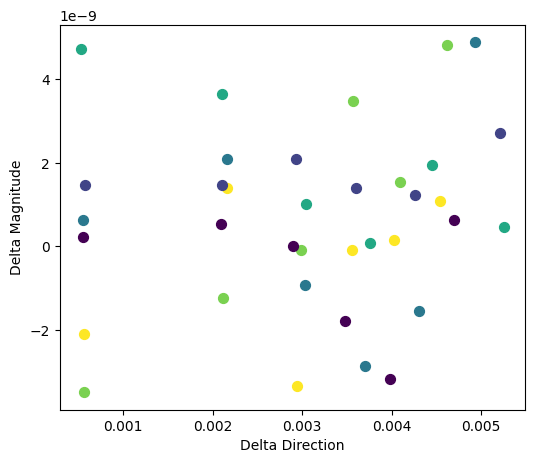

In [18]:
colors = plt.cm.viridis_r(np.linspace(0,1,len(query_layers)))

plt.figure(figsize=(6,5))
for i, (name, record) in enumerate(delta_records.items()):
    plt.scatter(record["delta_D"], record["delta_M"], label=name, color=colors[i], s=50)

plt.xlabel("Delta Direction")
plt.ylabel("Delta Magnitude")
##plt.legend()
plt.show()